# SP-GaRT : Complete Comparative Evaluation
## All Models × All Training Versions × Literature

Evaluates M1-M5 across three training regimes:
- **Original** - absolute position prediction
- **+VelRes** - velocity residual prediction
- **+VelAux** - velocity residual + velocity auxiliary loss

Produces 10 thesis-ready figures.

## 01. Setup

In [1]:
import torch, os, sys, math
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import OrderedDict

from google.colab import drive
drive.mount('/content/drive')

ROOT        = '/content/drive/MyDrive/L4_Research_Resources'
SAVE_ORIG   = f'{ROOT}/SP_GaRT/checkpoints'
SAVE_VR     = f'{ROOT}/SP_GaRT_VelRes/checkpoints'
SAVE_VA     = f'{ROOT}/SP_GaRT_VelAux/checkpoints'
LOG_ORIG    = f'{ROOT}/SP_GaRT/runs'
LOG_VR      = f'{ROOT}/SP_GaRT_VelRes/runs'
LOG_VA      = f'{ROOT}/SP_GaRT_VelAux/runs'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

if not os.path.exists('/content/SP_GaRT'):
    !git clone https://github.com/GayuniBas2001/SP-GaRT_Spatially_Pruned_Graph_Transformer.git /content/SP_GaRT
else:
    !cd /content/SP_GaRT && git pull --quiet
%cd /content/SP_GaRT
sys.path.insert(0, '/content/SP_GaRT')

DATA = '/content/SP_GaRT/data/data_3d_h36m.npz'
if not os.path.exists(DATA):
    !cp "{ROOT}/SP_GaRT/data/data_3d_h36m.npz" "{DATA}"

!pip install tensorboard -q

from data.h36m_dataset import build_dataloaders, SKELETON_EDGES_17
from utils.trainer import evaluate_model, measure_inference_time
from utils.metrics import mpjpe_at_horizons
from models.vanilla_transformer import VanillaTransformer
from models.graph_transformer import DenseGraphTransformer
from models.pruned_graph_transformer import PrunedGraphTransformer

_, test_loader = build_dataloaders(
    DATA, batch_size=32, t_obs=10, t_pred=25,
    train_stride=5, test_stride=1
)
test_dataset = test_loader.dataset
print(f'Test set: {len(test_dataset):,} windows')

Mounted at /content/drive
Device: cuda
GPU   : Tesla T4
Cloning into '/content/SP_GaRT'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 87 (delta 27), reused 68 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 369.85 KiB | 9.48 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/SP_GaRT
[H36MDataset] 38045 windows | subjects=['S1', 'S5', 'S6', 'S7', 'S8'] | t_obs=10 t_pred=25 | stride=5 | 25Hz
[H36MDataset] 65927 windows | subjects=['S9', 'S11'] | t_obs=10 t_pred=25 | stride=1 | 25Hz
Test set: 65,927 windows


## 02. Model Loading

In [2]:
class VelocityResidualWrapper(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base_model = base
        self._use_dct   = False
    def forward(self, obs):
        return obs[:, -1:, :, :] + self.base_model(obs)
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class ZeroVelocity(nn.Module):
    def forward(self, obs):
        return obs[:, -1:, :, :].expand(-1, 25, -1, -1)

GKW = dict(J=17,D=3,d_model=256,n_heads=4,n_st_layers=2,
            d_ff=512,dropout=0.1,t_obs=10,t_pred=25)
M1KW= dict(J=17,D=3,d_model=256,n_heads=4,n_enc_layers=2,
            n_dec_layers=2,d_ff=512,dropout=0.1,t_obs=10,t_pred=25)

def _load(cls, kw, name, ckpt_dir, wrap=False):
    path = f'{ckpt_dir}/{name}_best.pth'
    if not os.path.exists(path):
        print(f'  ✗ {name}')
        return None
    base = cls(**kw).to(device)
    m    = VelocityResidualWrapper(base).to(device) if wrap else base
    ckpt = torch.load(path, map_location=device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    print(f'  ✓ {name:<48} ep={ckpt["epoch"]:>3}  '
          f'best={ckpt["best_mpjpe"]:>7.1f}mm')
    return m

print('Original:')
orig = {
    'M1' : _load(VanillaTransformer,    M1KW,'M1_vanilla_transformer',      SAVE_ORIG),
    'M2' : _load(DenseGraphTransformer,  GKW, 'M2_dense_graph_transformer',  SAVE_ORIG),
    'M3a': _load(PrunedGraphTransformer, GKW, 'M3_pruned_graph_transformer', SAVE_ORIG),
    'M4' : _load(DenseGraphTransformer,  GKW, 'M4_SP_GaRT',                 SAVE_ORIG),
    'M5' : _load(PrunedGraphTransformer, GKW, 'M5_true_SP_GaRT',            SAVE_ORIG),
}

print('\n+VelRes:')
velres = {
    'M1' : _load(VanillaTransformer,    M1KW,'M1_VR_vanilla_transformer',       SAVE_VR, wrap=True),
    'M2' : _load(DenseGraphTransformer,  GKW, 'M2_VR_dense_graph_transformer',   SAVE_VR, wrap=True),
    'M3a': _load(PrunedGraphTransformer, GKW, 'M3a_VR_pruned_graph_transformer', SAVE_VR, wrap=True),
    'M4' : _load(DenseGraphTransformer,  GKW, 'M4_VR_SP_GaRT',                  SAVE_VR, wrap=True),
    'M5' : _load(PrunedGraphTransformer, GKW, 'M5_VR_true_SP_GaRT',             SAVE_VR, wrap=True),
}

print('\n+VelAux:')
velaux = {
    'M1' : _load(VanillaTransformer,    M1KW,'M1_VA_vanilla',       SAVE_VA, wrap=True),
    'M2' : _load(DenseGraphTransformer,  GKW, 'M2_VA_dense_graph',  SAVE_VA, wrap=True),
    'M3a': _load(PrunedGraphTransformer, GKW, 'M3a_VA_pruned_graph',SAVE_VA, wrap=True),
    'M4' : _load(DenseGraphTransformer,  GKW, 'M4_VA_SP_GaRT',      SAVE_VA, wrap=True),
    'M5' : _load(PrunedGraphTransformer, GKW, 'M5_VA_true_SP_GaRT', SAVE_VA, wrap=True),
}

zv = ZeroVelocity().to(device)
print('\nAll models loaded.')

Original:
  ✓ M1_vanilla_transformer                           ep= 50  best=  112.2mm
  ✓ M2_dense_graph_transformer                       ep= 40  best=  105.8mm
  ✓ M3_pruned_graph_transformer                      ep= 35  best=  103.0mm
  ✓ M4_SP_GaRT                                       ep= 35  best=  104.6mm
  ✓ M5_true_SP_GaRT                                  ep= 25  best=  101.5mm

+VelRes:
  ✓ M1_VR_vanilla_transformer                        ep=  5  best=  103.5mm
  ✓ M2_VR_dense_graph_transformer                    ep= 20  best=   96.3mm
  ✓ M3a_VR_pruned_graph_transformer                  ep= 30  best=   97.5mm
  ✓ M4_VR_SP_GaRT                                    ep= 15  best=   96.2mm
  ✓ M5_VR_true_SP_GaRT                               ep= 20  best=   94.8mm

+VelAux:
  ✓ M1_VA_vanilla                                    ep= 35  best=   98.5mm
  ✓ M2_VA_dense_graph                                ep= 20  best=   95.2mm
  ✓ M3a_VA_pruned_graph                              ep= 3

## 03. Evaluate on Full Test Set

In [3]:
KEYS = ['M1','M2','M3a','M4','M5']
HS   = [80,160,320,560,1000]

def eval_dict(model_dict, label):
    res, spd = {}, {}
    print(f'\nEvaluating {label}...')
    for k, m in model_dict.items():
        if m is None:
            continue
        r    = evaluate_model(m, test_loader, device)
        ms,_ = measure_inference_time(m, device)
        res[k] = r; spd[k] = ms
        gvr = r['gvr'] or 0
        print(f'  {k}: {r["mpjpe"][560]:>7.1f}mm  '
              f'GVR={gvr:.4f}  BLE={r["ble"]:.2f}mm  {ms:.2f}ms')
    return res, spd

res_zv = evaluate_model(zv, test_loader, device)
print(f'Zero-Velocity: {res_zv["mpjpe"][560]:.1f}mm  '
      f'GVR={res_zv["gvr"] or 0:.4f}')

r_orig,   s_orig   = eval_dict(orig,   'Original')
r_vr,     s_vr     = eval_dict(velres, '+VelRes')
r_va,     s_va     = eval_dict(velaux, '+VelAux')

print('\nAll evaluations complete.')

Zero-Velocity: 179.4mm  GVR=0.0274

Evaluating Original...
  M1:   142.4mm  GVR=0.0548  BLE=23.37mm  3.34ms
  M2:   119.1mm  GVR=0.0200  BLE=24.14mm  4.41ms
  M3a:   115.7mm  GVR=0.0504  BLE=22.18mm  5.78ms
  M4:   115.9mm  GVR=0.0073  BLE=23.97mm  4.65ms
  M5:   118.4mm  GVR=0.0074  BLE=22.82mm  7.21ms

Evaluating +VelRes...
  M1:   115.3mm  GVR=0.0325  BLE=9.72mm  2.70ms
  M2:    99.8mm  GVR=0.0207  BLE=12.17mm  4.28ms
  M3a:   100.7mm  GVR=0.0196  BLE=12.19mm  5.13ms
  M4:   100.8mm  GVR=0.0075  BLE=12.29mm  4.41ms
  M5:   100.1mm  GVR=0.0066  BLE=13.08mm  5.00ms

Evaluating +VelAux...
  M1:   109.2mm  GVR=0.0276  BLE=8.96mm  2.54ms
  M2:   100.9mm  GVR=0.0171  BLE=11.28mm  4.33ms
  M3a:   100.5mm  GVR=0.0189  BLE=11.22mm  5.22ms
  M4:    97.5mm  GVR=0.0126  BLE=11.64mm  4.38ms
  M5:   100.1mm  GVR=0.0074  BLE=12.56mm  6.02ms

All evaluations complete.


## 04. Master Comparison Tables

In [4]:
def ptable(label, res, spd):
    print(f'\n  [{label}]')
    print(f'  {"Model":<8} {"80ms":>7}{"160ms":>7}{"320ms":>7}'
          f'{"560ms":>7}{"1000ms":>8}{"ADE":>7}'
          f'{"GVR":>8}{"BLE":>7}{"ms":>6}')
    print(f'  {"-"*75}')
    for k in KEYS:
        r = res.get(k)
        if r is None:
            print(f'  {k:<8}  — (not loaded)')
            continue
        gvr = r['gvr'] or 0
        print(f'  {k:<8}'
              f'{r["mpjpe"][80]:>7.1f}'
              f'{r["mpjpe"][160]:>7.1f}'
              f'{r["mpjpe"][320]:>7.1f}'
              f'{r["mpjpe"][560]:>7.1f}'
              f'{r["mpjpe"][1000]:>8.1f}'
              f'{r["ade"]:>7.1f}'
              f'{gvr:>8.4f}'
              f'{r["ble"]:>7.2f}'
              f'{spd.get(k,0):>6.2f}')

print('='*80)
print('SP-GaRT COMPLETE ABLATION TABLE')
print('Human3.6M | 17 joints | 25Hz | full test set S9+S11')
print('='*80)

zv_gvr = res_zv['gvr'] or 0
print(f'\n  [Zero-Velocity baseline]')
print(f'  {"ZV":<8}'
      f'{res_zv["mpjpe"][80]:>7.1f}'
      f'{res_zv["mpjpe"][160]:>7.1f}'
      f'{res_zv["mpjpe"][320]:>7.1f}'
      f'{res_zv["mpjpe"][560]:>7.1f}'
      f'{res_zv["mpjpe"][1000]:>8.1f}'
      f'{res_zv["ade"]:>7.1f}'
      f'{zv_gvr:>8.4f}'
      f'{res_zv["ble"]:>7.2f}   —')

ptable('Original',  r_orig, s_orig)
ptable('+VelRes',   r_vr,   s_vr)
ptable('+VelAux',   r_va,   s_va)
print('='*80)

SP-GaRT COMPLETE ABLATION TABLE
Human3.6M | 17 joints | 25Hz | full test set S9+S11

  [Zero-Velocity baseline]
  ZV         28.4   56.0  108.0  179.4   295.2  163.3  0.0274   0.00   —

  [Original]
  Model       80ms  160ms  320ms  560ms  1000ms    ADE     GVR    BLE    ms
  ---------------------------------------------------------------------------
  M1         83.3   89.1  107.8  142.4   207.3  138.6  0.0548  23.37  3.34
  M2         61.6   67.1   85.3  119.1   183.8  115.6  0.0200  24.14  4.41
  M3a        58.9   64.3   82.5  115.7   179.7  112.3  0.0504  22.18  5.78
  M4         58.1   63.9   82.6  115.9   180.7  112.5  0.0073  23.97  4.65
  M5         63.7   68.6   85.8  118.4   182.9  115.6  0.0074  22.82  7.21

  [+VelRes]
  Model       80ms  160ms  320ms  560ms  1000ms    ADE     GVR    BLE    ms
  ---------------------------------------------------------------------------
  M1         28.3   44.4   74.1  115.3   189.7  107.6  0.0325   9.72  2.70
  M2         22.8   35.0   60.

In [5]:
# Improvement summary
m1_base  = r_orig.get('M1',{}).get('mpjpe',{}).get(560,0)
m1_gvr   = r_orig.get('M1',{}).get('gvr') or 0

print('\nIMPROVEMENT vs M1 Original at 560ms')
print('='*70)
print(f'{"Model+Version":<28}{"MPJPE":>8}{"vs M1":>8}{"GVR":>8}{"GVR red":>9}')
print('-'*70)

for label, res in [('Original',r_orig),('+VelRes',r_vr),('+VelAux',r_va)]:
    for k in KEYS:
        r = res.get(k)
        if not r:
            continue
        mpjpe    = r['mpjpe'][560]
        gvr      = r['gvr'] or 0
        pct_mpjpe= (m1_base-mpjpe)/m1_base*100 if m1_base else 0
        pct_gvr  = (m1_gvr-gvr)/m1_gvr*100 if m1_gvr else 0
        print(f'{k+" "+label:<28}{mpjpe:>8.1f}{pct_mpjpe:>7.1f}%'
              f'{gvr:>8.4f}{pct_gvr:>8.1f}%')
print('='*70)


IMPROVEMENT vs M1 Original at 560ms
Model+Version                  MPJPE   vs M1     GVR  GVR red
----------------------------------------------------------------------
M1 Original                    142.4    0.0%  0.0548     0.0%
M2 Original                    119.1   16.4%  0.0200    63.4%
M3a Original                   115.7   18.7%  0.0504     7.9%
M4 Original                    115.9   18.6%  0.0073    86.7%
M5 Original                    118.4   16.8%  0.0074    86.4%
M1 +VelRes                     115.3   19.0%  0.0325    40.6%
M2 +VelRes                      99.8   29.9%  0.0207    62.1%
M3a +VelRes                    100.7   29.3%  0.0196    64.2%
M4 +VelRes                     100.8   29.2%  0.0075    86.3%
M5 +VelRes                     100.1   29.7%  0.0066    87.9%
M1 +VelAux                     109.2   23.3%  0.0276    49.6%
M2 +VelAux                     100.9   29.1%  0.0171    68.8%
M3a +VelAux                    100.5   29.4%  0.0189    65.5%
M4 +VelAux              

## 05. Figures

In [19]:
# Shared style
BG   = '#ffffff'
AX   = '#ffffff'
GRID = '#e0e0e0'
MC   = {'M1':'#ff6b6b','M2':'#4ecdc4','M3a':'#ffd93d',
         'M4':'#a8e6cf','M5':'#c084fc','ZV':'#555555'}
VC   = {'Original':'#4488cc','+VelRes':'#44aacc','+VelAux':'#44ccaa'}

def sax(ax):
    ax.set_facecolor(AX)
    ax.tick_params(colors='#333',labelsize=9)
    for sp in ax.spines.values(): sp.set_color('#888')
    ax.grid(True,color=GRID,linestyle='--',alpha=0.7)
    ax.xaxis.label.set_color('#333')
    ax.yaxis.label.set_color('#333')
    ax.title.set_color('black')

VER = [('Original',r_orig), ('+VelRes',r_vr), ('+VelAux',r_va)]
print('Style helpers ready.')

Style helpers ready.


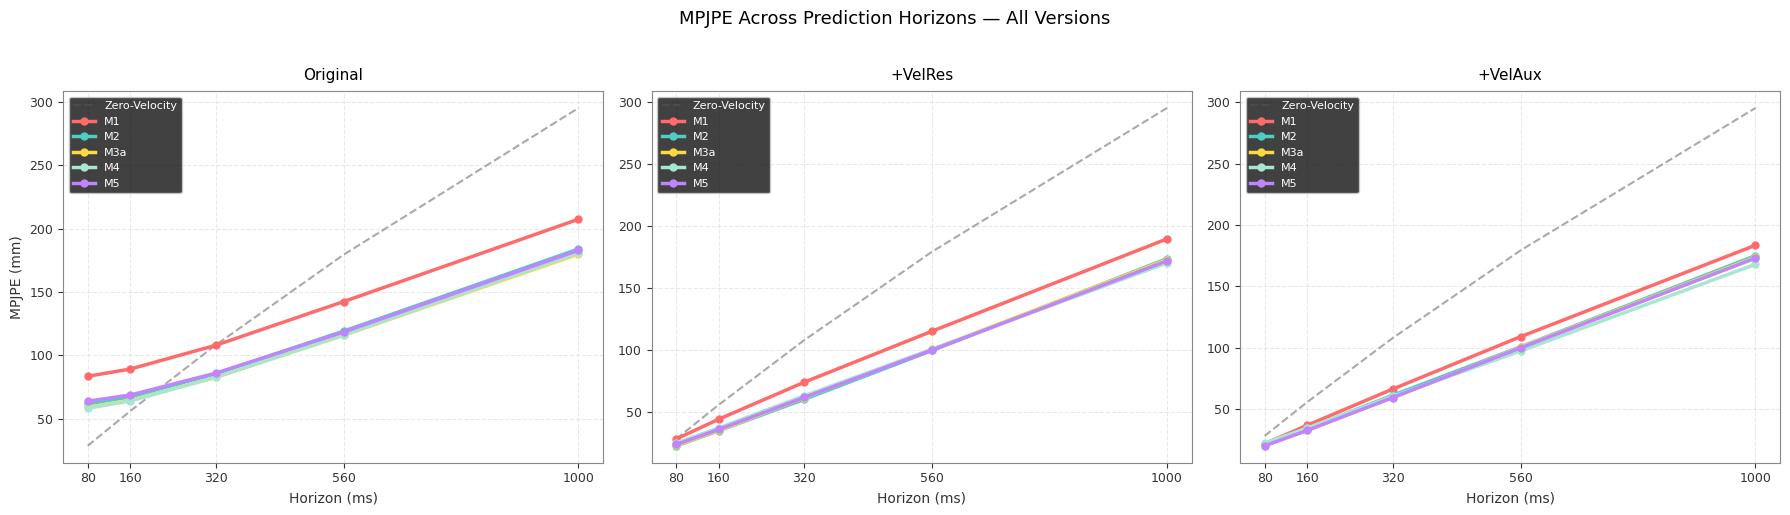

Saved: fig1_mpjpe_horizons.png


In [36]:
# ── Fig 1: MPJPE across horizons, three-panel ─────────────────
fig, axes = plt.subplots(1,3,figsize=(18,5),sharey=False)
fig.patch.set_facecolor(BG)
fig.suptitle('MPJPE Across Prediction Horizons — All Versions',
             color='black',fontsize=13,y=1.02)

for ax,(vname,res) in zip(axes,VER):
    sax(ax)
    zv_v = [res_zv['mpjpe'][h] for h in HS]
    ax.plot(HS,zv_v,color=MC['ZV'],ls='--',lw=1.5,alpha=0.5,label='Zero-Velocity')
    for k in KEYS:
        r = res.get(k)
        if not r: continue
        ax.plot(HS,[r['mpjpe'][h] for h in HS],
                color=MC[k],lw=2.5,marker='o',ms=5,label=k)
    ax.set_title(vname,fontsize=11,pad=8)
    ax.set_xlabel('Horizon (ms)',fontsize=10)
    ax.set_xticks(HS)
    ax.legend(facecolor='#111',labelcolor='white',fontsize=8,framealpha=0.8)

axes[0].set_ylabel('MPJPE (mm)',fontsize=10)
plt.tight_layout()
plt.savefig('fig1_mpjpe_horizons.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig1_mpjpe_horizons.png')

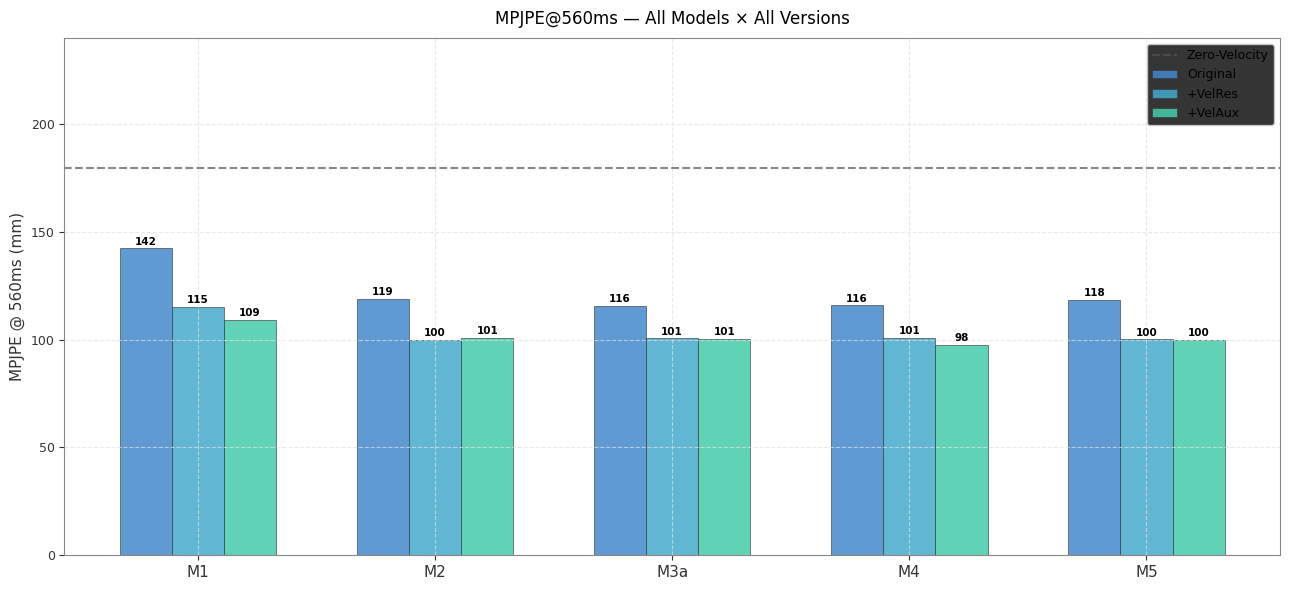

Saved: fig2_mpjpe_grouped.png


In [25]:
# ── Fig 2: Grouped bars — MPJPE@560ms ─────────────────────────
fig,ax = plt.subplots(figsize=(13,6))
fig.patch.set_facecolor(BG); sax(ax)

bw = 0.22; x = np.arange(len(KEYS))
offs = [-bw, 0, bw]

for (vname,res),off in zip(VER,offs):
    vals=[res.get(k,{}).get('mpjpe',{}).get(560,0) for k in KEYS]
    bars=ax.bar(x+off,vals,width=bw,color=VC[vname],
                 alpha=0.85,edgecolor='#333',lw=0.5,label=vname)
    for bar,v in zip(bars,vals):
        if v>0:
            ax.text(bar.get_x()+bar.get_width()/2,v+0.8,
                     f'{v:.0f}',ha='center',va='bottom',
                     color='black',fontsize=7.5,fontweight='bold')

ax.axhline(y=res_zv['mpjpe'][560],color=MC['ZV'],ls='--',
            lw=1.5,alpha=0.7,label='Zero-Velocity')
ax.set_xticks(x); ax.set_xticklabels(KEYS,fontsize=11)
ax.set_ylabel('MPJPE @ 560ms (mm)',fontsize=11)
ax.set_title('MPJPE@560ms — All Models × All Versions',fontsize=12,pad=10)
ax.legend(facecolor='#111',labelcolor='black',fontsize=9,framealpha=0.85)
ax.set_ylim(0,max(res_zv['mpjpe'][560]*1.2,240))
plt.tight_layout()
plt.savefig('fig2_mpjpe_grouped.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig2_mpjpe_grouped.png')

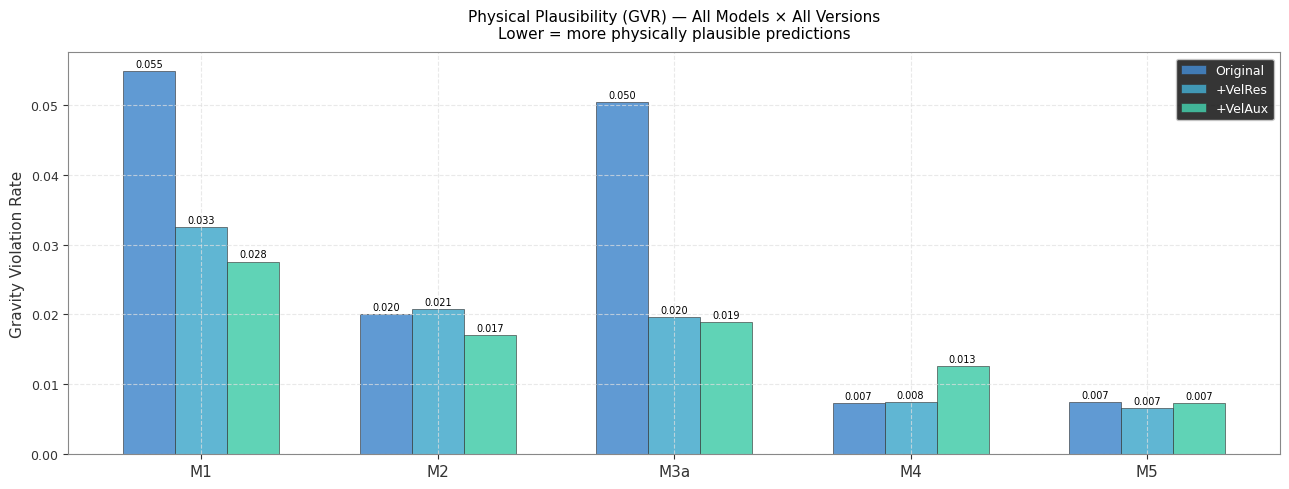

Saved: fig3_gvr_grouped.png


In [27]:
# ── Fig 3: GVR grouped bars ────────────────────────────────────
fig,ax = plt.subplots(figsize=(13,5))
fig.patch.set_facecolor(BG); sax(ax)

for (vname,res),off in zip(VER,offs):
    vals=[(res.get(k,{}).get('gvr') or 0) for k in KEYS]
    bars=ax.bar(x+off,vals,width=bw,color=VC[vname],
                 alpha=0.85,edgecolor='#333',lw=0.5,label=vname)
    for bar,v in zip(bars,vals):
        if v>0.001:
            ax.text(bar.get_x()+bar.get_width()/2,v+0.0003,
                     f'{v:.3f}',ha='center',va='bottom',
                     color='black',fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(KEYS,fontsize=11)
ax.set_ylabel('Gravity Violation Rate',fontsize=11)
ax.set_title('Physical Plausibility (GVR) — All Models × All Versions\n'
              'Lower = more physically plausible predictions',fontsize=11,pad=10)
ax.legend(facecolor='#111',labelcolor='white',fontsize=9,framealpha=0.85)
plt.tight_layout()
plt.savefig('fig3_gvr_grouped.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig3_gvr_grouped.png')

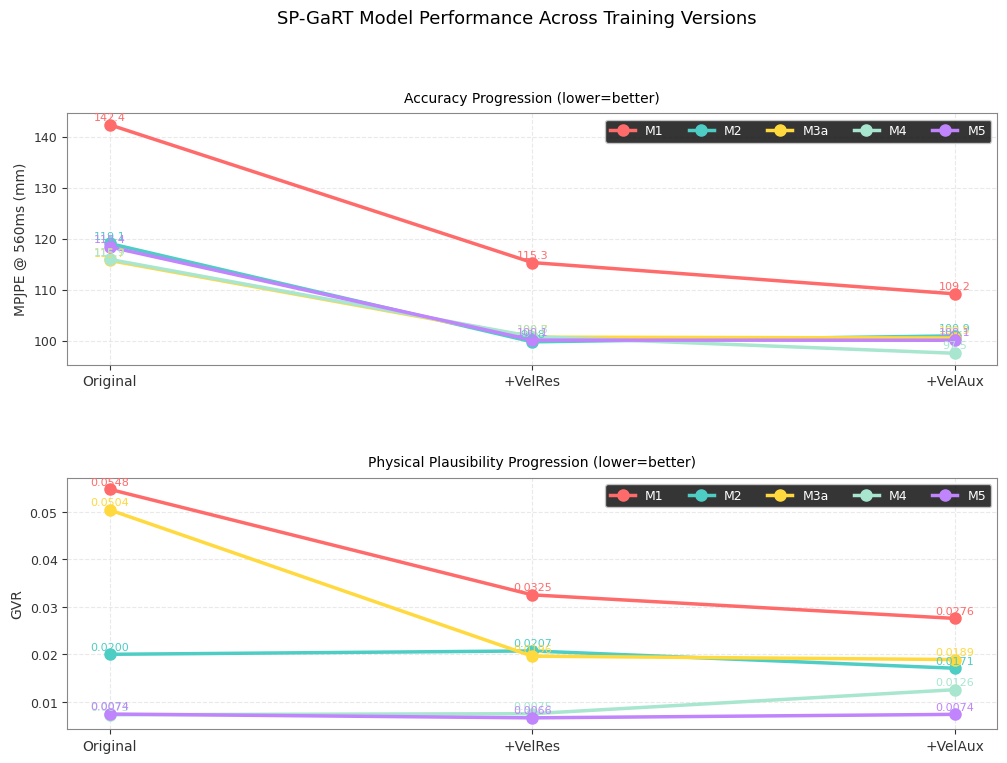

Saved: fig4_progression.png


In [29]:
# ── Fig 4: Progression lines — MPJPE and GVR per model ────────
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,8),
                             gridspec_kw={'hspace':0.45})
fig.patch.set_facecolor(BG)

ver_labels=['Original','+VelRes','+VelAux']
ver_res   =[r_orig,r_vr,r_va]

for ax,mkey,yl,ttl in [
    (ax1,'mpjpe','MPJPE @ 560ms (mm)','Accuracy Progression (lower=better)'),
    (ax2,'gvr',  'GVR',               'Physical Plausibility Progression (lower=better)'),
]:
    sax(ax)
    for k in KEYS:
        c=MC[k]; xs=[]; ys=[]
        for i,res in enumerate(ver_res):
            r=res.get(k)
            if r is None: continue
            val=r['mpjpe'][560] if mkey=='mpjpe' else (r['gvr'] or 0)
            xs.append(i); ys.append(val)
        if not xs: continue
        ax.plot(xs,ys,color=c,lw=2.5,marker='o',ms=8,label=k)
        for xi,yi in zip(xs,ys):
            off=0.5 if mkey=='mpjpe' else 0.0005
            fmt=f'{yi:.1f}' if mkey=='mpjpe' else f'{yi:.4f}'
            ax.text(xi,yi+off,fmt,ha='center',va='bottom',
                     color=c,fontsize=8)
    ax.set_xticks(range(len(ver_labels)))
    ax.set_xticklabels(ver_labels,fontsize=10)
    ax.set_ylabel(yl,fontsize=10)
    ax.set_title(ttl,fontsize=10,pad=8)
    ax.legend(facecolor='#111',labelcolor='white',
               fontsize=9,framealpha=0.85,ncol=5)

fig.suptitle('SP-GaRT Model Performance Across Training Versions',
              color='black',fontsize=13,y=1.01)
plt.savefig('fig4_progression.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig4_progression.png')

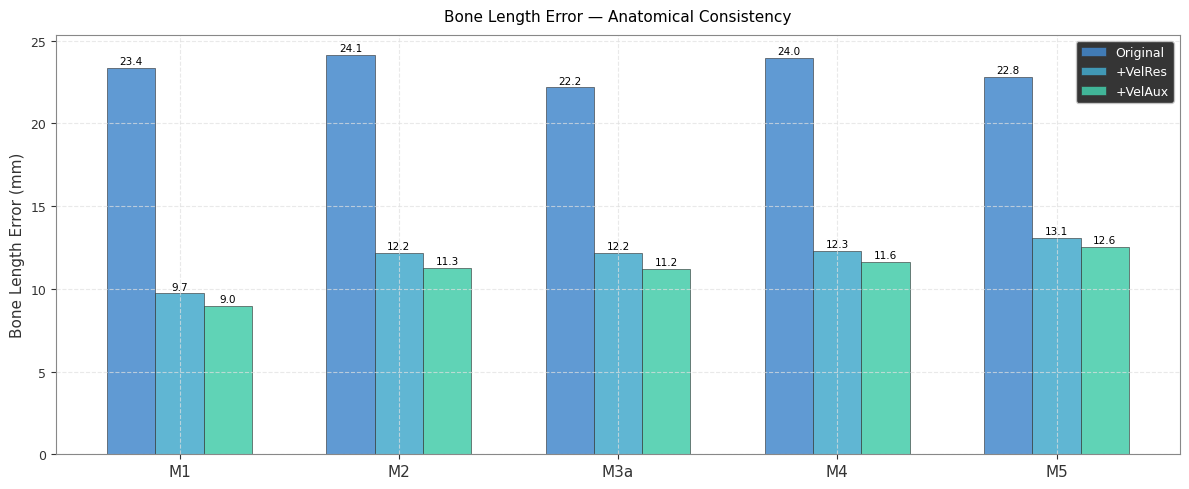

Saved: fig5_ble.png


In [30]:
# ── Fig 5: BLE comparison ──────────────────────────────────────
fig,ax=plt.subplots(figsize=(12,5))
fig.patch.set_facecolor(BG); sax(ax)

for (vname,res),off in zip(VER,offs):
    vals=[(res.get(k,{}).get('ble') or 0) for k in KEYS]
    bars=ax.bar(x+off,vals,width=bw,color=VC[vname],
                 alpha=0.85,edgecolor='#333',lw=0.5,label=vname)
    for bar,v in zip(bars,vals):
        if v>0:
            ax.text(bar.get_x()+bar.get_width()/2,v+0.1,
                     f'{v:.1f}',ha='center',va='bottom',
                     color='black',fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(KEYS,fontsize=11)
ax.set_ylabel('Bone Length Error (mm)',fontsize=11)
ax.set_title('Bone Length Error — Anatomical Consistency',fontsize=11,pad=10)
ax.legend(facecolor='#111',labelcolor='white',fontsize=9,framealpha=0.85)
plt.tight_layout()
plt.savefig('fig5_ble.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig5_ble.png')

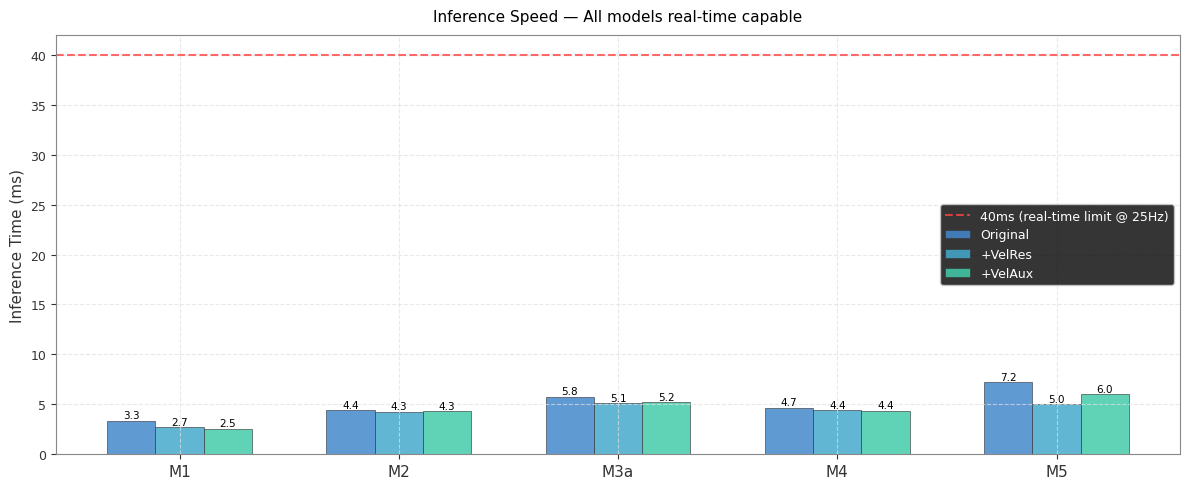

Saved: fig6_inference.png


In [37]:
# ── Fig 6: Inference speed ─────────────────────────────────────
fig,ax=plt.subplots(figsize=(12,5))
fig.patch.set_facecolor(BG); sax(ax)

spds=[s_orig,s_vr,s_va]
for (vname,_),spd,off in zip(VER,spds,offs):
    vals=[spd.get(k,0) for k in KEYS]
    bars=ax.bar(x+off,vals,width=bw,color=VC[vname],
                 alpha=0.85,edgecolor='#333',lw=0.5,label=vname)
    for bar,v in zip(bars,vals):
        if v>0:
            ax.text(bar.get_x()+bar.get_width()/2,v+0.05,
                     f'{v:.1f}',ha='center',va='bottom',
                     color='black',fontsize=7.5)

ax.axhline(y=40,color='#ff4444',ls='--',lw=1.5,
            alpha=0.8,label='40ms (real-time limit @ 25Hz)')
ax.set_xticks(x); ax.set_xticklabels(KEYS,fontsize=11)
ax.set_ylabel('Inference Time (ms)',fontsize=11)
ax.set_title('Inference Speed — All models real-time capable',fontsize=11,pad=10)
ax.legend(facecolor='#111',labelcolor='white',fontsize=9,framealpha=0.85)
plt.tight_layout()
plt.savefig('fig6_inference.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig6_inference.png')

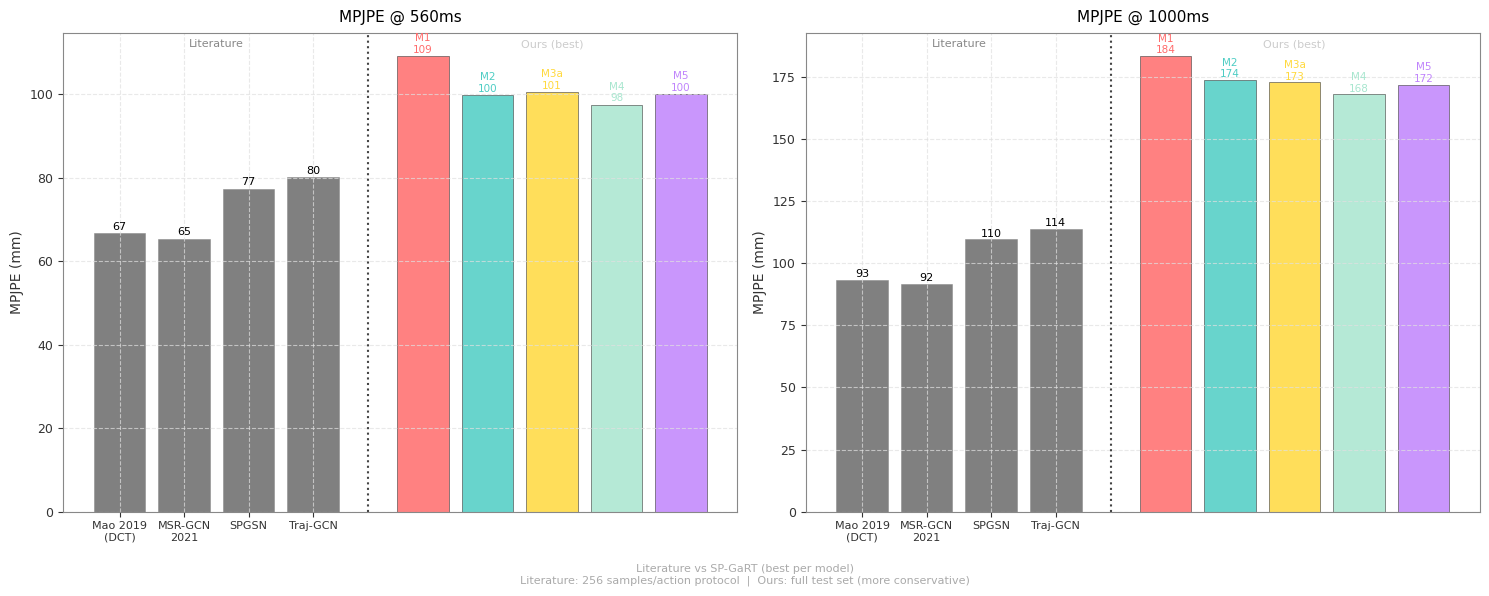

Saved: fig7_literature.png


In [32]:
# ── Fig 7: Literature comparison bar ──────────────────────────
lit_names = ['Mao 2019\n(DCT)','MSR-GCN\n2021','SPGSN','Traj-GCN']
lit_560   = [66.7, 65.4, 77.4, 80.2]
lit_1000  = [93.4, 91.7,109.6,113.9]

# Our best per model across versions
our_560 = {}
our_1000= {}
for k in KEYS:
    v560  = [r.get(k,{}).get('mpjpe',{}).get(560,999)  for r in [r_orig,r_vr,r_va]]
    v1000 = [r.get(k,{}).get('mpjpe',{}).get(1000,999) for r in [r_orig,r_vr,r_va]]
    our_560[k]  = min(v for v in v560  if v<999)
    our_1000[k] = min(v for v in v1000 if v<999)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))
fig.patch.set_facecolor(BG)

for ax,(hz,lvals,odict) in zip(
    [ax1,ax2],
    [(560,lit_560,our_560),(1000,lit_1000,our_1000)]
):
    sax(ax)
    n_lit=len(lit_names)

    lb=ax.bar(range(n_lit),lvals,color='#555555',
               alpha=0.75,edgecolor='#888',lw=0.5,label='Literature')
    for bar,v in zip(lb,lvals):
        ax.text(bar.get_x()+bar.get_width()/2,v+0.3,
                 f'{v:.0f}',ha='center',va='bottom',color='black',fontsize=8)

    off=n_lit+0.7
    our_ks=[k for k in KEYS if k in odict]
    our_vs=[odict[k] for k in our_ks]
    our_cs=[MC[k] for k in our_ks]
    ob=ax.bar([off+i for i in range(len(our_ks))],
               our_vs,color=our_cs,alpha=0.85,edgecolor='#444',lw=0.5)
    for bar,v,k in zip(ob,our_vs,our_ks):
        ax.text(bar.get_x()+bar.get_width()/2,v+0.3,
                 f'{k}\n{v:.0f}',ha='center',va='bottom',
                 color=MC[k],fontsize=7.5)

    ax.axvline(x=n_lit-0.15,color='#444',ls=':',lw=1.5)
    ax.text(n_lit/2-0.5, ax.get_ylim()[1]*0.97,'Literature',
             ha='center',color='#888',fontsize=8)
    ax.text(off+len(our_ks)/2-0.5, ax.get_ylim()[1]*0.97,'Ours (best)',
             ha='center',color='#ccc',fontsize=8)

    all_x=list(range(n_lit))+[off+i for i in range(len(our_ks))]
    all_l=lit_names+['']*(len(our_ks))
    ax.set_xticks(all_x[:n_lit])
    ax.set_xticklabels(lit_names,fontsize=8)
    ax.set_ylabel('MPJPE (mm)',fontsize=10)
    ax.set_title(f'MPJPE @ {hz}ms',fontsize=11,pad=8)

fig.suptitle(
    'Literature vs SP-GaRT (best per model)\n'
    'Literature: 256 samples/action protocol  |  '
    'Ours: full test set (more conservative)',
    color='#aaa',fontsize=8,y=-0.01
)
plt.tight_layout()
plt.savefig('fig7_literature.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig7_literature.png')

In [14]:
# ── Fig 8: Training convergence from TensorBoard ───────────────
from tensorboard.backend.event_processing.event_accumulator \
    import EventAccumulator

def tb_load(logdir, tags=['Loss/train','MPJPE/560ms']):
    if not os.path.exists(logdir): return {}
    ea = EventAccumulator(logdir); ea.Reload()
    av = ea.Tags()['scalars']
    out= {}
    for t in tags:
        real_t = t
        if t=='Loss/train' and t not in av and 'Loss/total' in av:
            real_t='Loss/total'
        if real_t in av:
            ev=ea.Scalars(real_t)
            out[t]={'steps':[e.step for e in ev],
                     'values':[e.value for e in ev]}
    return out

log_cfg = {
    'Original':{
        'M1':'M1_vanilla_transformer','M2':'M2_dense_graph_transformer',
        'M3a':'M3_pruned_graph_transformer','M4':'M4_SP_GaRT','M5':'M5_true_SP_GaRT'
    },
    '+VelRes':{
        'M1':'M1_VR_vanilla_transformer','M2':'M2_VR_dense_graph_transformer',
        'M3a':'M3a_VR_pruned_graph_transformer','M4':'M4_VR_SP_GaRT','M5':'M5_VR_true_SP_GaRT'
    },
    '+VelAux':{
        'M1':'M1_VA_vanilla','M2':'M2_VA_dense_graph',
        'M3a':'M3a_VA_pruned_graph','M4':'M4_VA_SP_GaRT','M5':'M5_VA_true_SP_GaRT'
    },
}
log_root = {'Original':LOG_ORIG,'+VelRes':LOG_VR,'+VelAux':LOG_VA}

logs={}
for vn,mmap in log_cfg.items():
    logs[vn]={}
    for k,folder in mmap.items():
        d=tb_load(f'{log_root[vn]}/{folder}')
        if d: logs[vn][k]=d

print('Logs loaded:')
for vn,ml in logs.items():
    print(f'  {vn}: {list(ml.keys())}')

Logs loaded:
  Original: ['M1', 'M2', 'M3a', 'M4', 'M5']
  +VelRes: ['M1', 'M2', 'M3a', 'M4', 'M5']
  +VelAux: ['M1', 'M2', 'M3a', 'M4', 'M5']


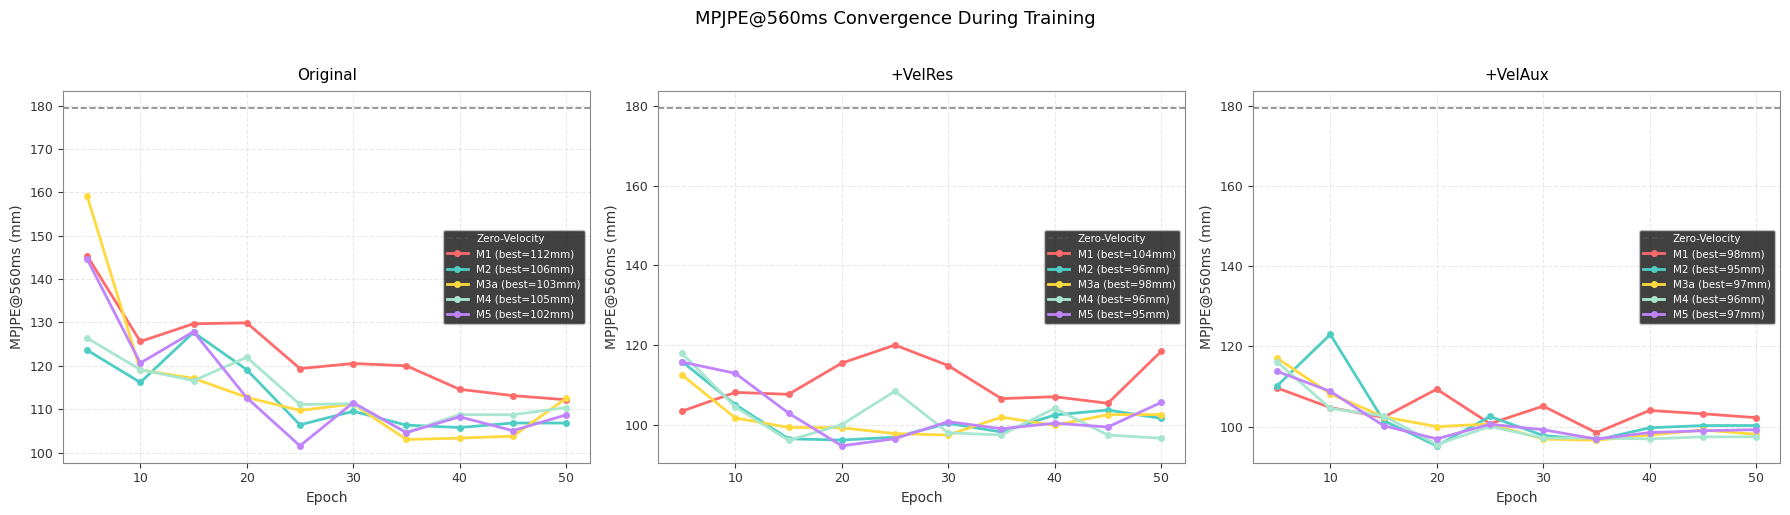

Saved: fig8_convergence.png


In [33]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.patch.set_facecolor(BG)
fig.suptitle('MPJPE@560ms Convergence During Training',
             color='black',fontsize=13,y=1.02)

for ax,vname in zip(axes,['Original','+VelRes','+VelAux']):
    sax(ax)
    ax.axhline(y=res_zv['mpjpe'][560],color='#555',
                ls='--',lw=1.2,alpha=0.7,label='Zero-Velocity')
    for k in KEYS:
        d=logs.get(vname,{}).get(k,{})
        if 'MPJPE/560ms' not in d: continue
        st=d['MPJPE/560ms']['steps']
        vl=d['MPJPE/560ms']['values']
        ax.plot(st,vl,color=MC[k],lw=2,marker='o',ms=4,
                 label=f'{k} (best={min(vl):.0f}mm)')
    ax.set_title(vname,fontsize=11,pad=8)
    ax.set_xlabel('Epoch',fontsize=10)
    ax.set_ylabel('MPJPE@560ms (mm)',fontsize=10)
    ax.legend(facecolor='#111',labelcolor='white',fontsize=7.5,framealpha=0.8)

plt.tight_layout()
plt.savefig('fig8_convergence.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig8_convergence.png')

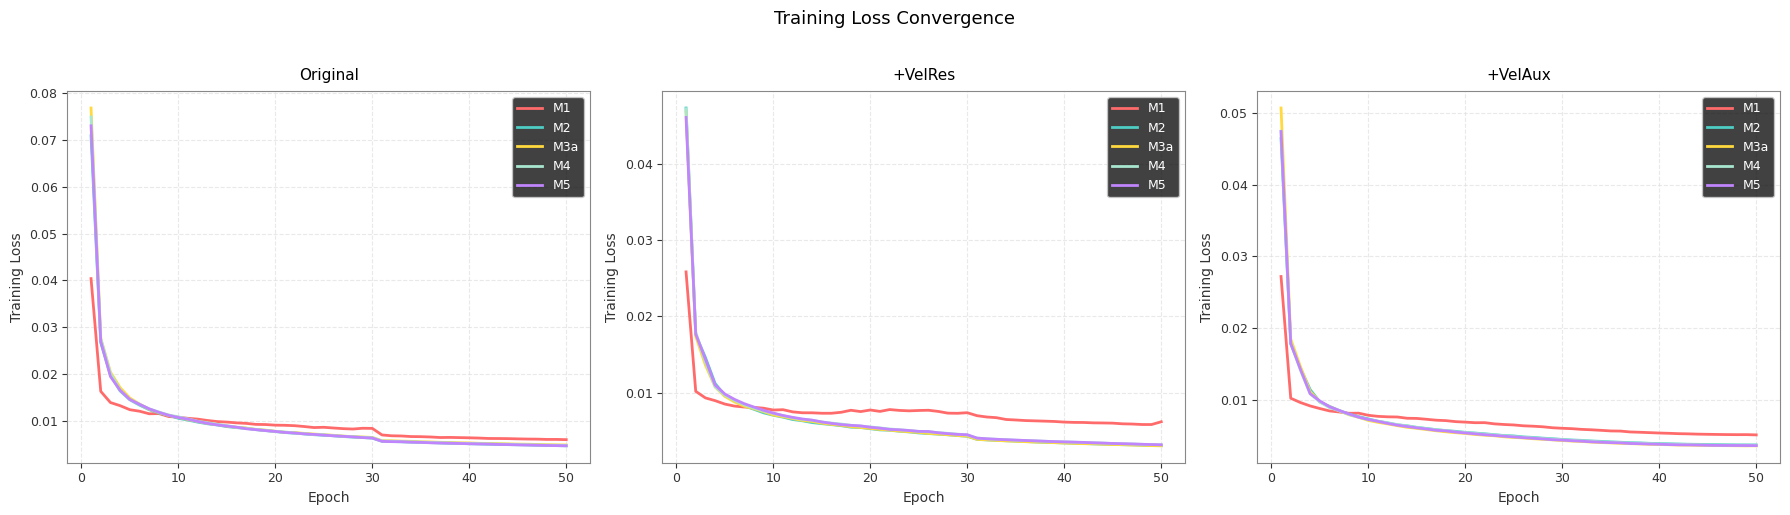

Saved: fig9_loss.png


In [38]:
# ── Fig 9: Training loss curves ────────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.patch.set_facecolor(BG)
fig.suptitle('Training Loss Convergence',color='black',fontsize=13,y=1.02)

for ax,vname in zip(axes,['Original','+VelRes','+VelAux']):
    sax(ax)
    for k in KEYS:
        d=logs.get(vname,{}).get(k,{})
        if 'Loss/train' not in d: continue
        ax.plot(d['Loss/train']['steps'],d['Loss/train']['values'],
                 color=MC[k],lw=2,label=k)
    ax.set_title(vname,fontsize=11,pad=8)
    ax.set_xlabel('Epoch',fontsize=10)
    ax.set_ylabel('Training Loss',fontsize=10)
    ax.legend(facecolor='#111',labelcolor='white',fontsize=9,framealpha=0.8)

plt.tight_layout()
plt.savefig('fig9_loss.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig9_loss.png')

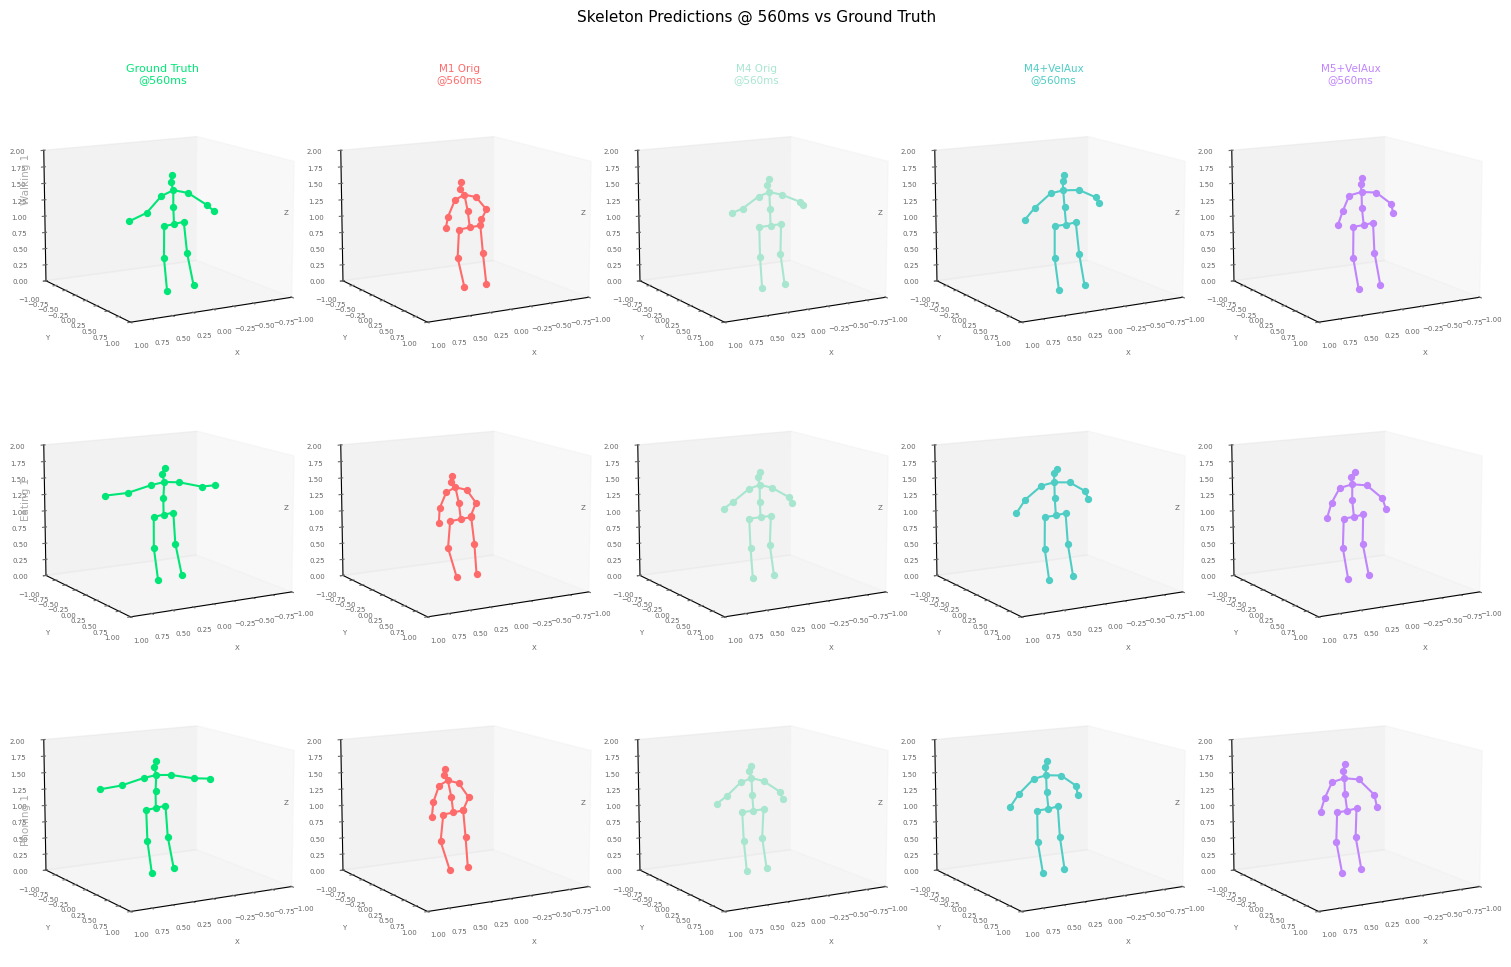

Saved: fig10_skeletons.png


In [39]:
# ── Fig 10: Skeleton predictions at 560ms ─────────────────────
def find_act(ds,kw,n=1):
    return [i for i,(s,a) in enumerate(ds.metadata)
             if kw.lower() in a.lower()][:n]

VIS = (find_act(test_dataset,'Walking',1)+
        find_act(test_dataset,'Eating',1)+
        find_act(test_dataset,'Phoning',1))[:3]

SHOW = OrderedDict([
    ('M1 Orig', orig.get('M1')),
    ('M4 Orig', orig.get('M4')),
    ('M4+VelAux',velaux.get('M4')),
    ('M5+VelAux',velaux.get('M5')),
])
SHOW = {k:v for k,v in SHOW.items() if v is not None}

SCOL={'GT':'#00e676','M1 Orig':'#ff6b6b','M4 Orig':'#a8e6cf',
       'M4+VelAux':'#4ecdc4','M5+VelAux':'#c084fc'}

FRM = 13  # 560ms at 25Hz

def pskel(ax,pose,col,alpha=1.0):
    if torch.is_tensor(pose): pose=pose.cpu().numpy()
    ax.scatter(pose[:,0],pose[:,1],pose[:,2],
               c=col,s=18,alpha=alpha,depthshade=False)
    for i,j in SKELETON_EDGES_17:
        ax.plot([pose[i,0],pose[j,0]],[pose[i,1],pose[j,1]],
                [pose[i,2],pose[j,2]],color=col,lw=1.5,alpha=alpha)
    ax.set_facecolor(AX)
    ax.set_xlim(-1,1);ax.set_ylim(-1,1);ax.set_zlim(0,2)
    ax.tick_params(labelsize=5,colors='#666')
    ax.set_xlabel('X',fontsize=5,color='#666')
    ax.set_ylabel('Y',fontsize=5,color='#666')
    ax.set_zlabel('Z',fontsize=5,color='#666')
    ax.view_init(elev=12,azim=60); ax.grid(False)

nr=len(VIS); nc=1+len(SHOW)
fig=plt.figure(figsize=(nc*3,nr*3.2))
fig.patch.set_facecolor(BG)

for ri,idx in enumerate(VIS):
    samp=test_dataset[idx]
    obs=samp['observed'].unsqueeze(0).to(device)
    fut=samp['future'].unsqueeze(0).to(device)
    act=test_dataset.metadata[idx][1]

    preds={}
    for mn,mo in SHOW.items():
        mo.eval()
        with torch.no_grad():
            preds[mn]=mo(obs)[0]

    ax=fig.add_subplot(nr,nc,ri*nc+1,projection='3d')
    pskel(ax,fut[0,FRM],SCOL['GT'])
    if ri==0: ax.set_title('Ground Truth\n@560ms',color=SCOL['GT'],fontsize=8,pad=2)
    fig.text(0.01,1-(ri+0.5)/nr,act[:16],va='center',
              color='#aaa',fontsize=7.5,rotation=90)

    for ci,(mn,pred) in enumerate(preds.items()):
        ax=fig.add_subplot(nr,nc,ri*nc+ci+2,projection='3d')
        pskel(ax,pred[FRM],SCOL.get(mn,'#fff'))
        if ri==0:
            ax.set_title(f'{mn}\n@560ms',
                          color=SCOL.get(mn,'#fff'),fontsize=7.5,pad=2)

fig.suptitle('Skeleton Predictions @ 560ms vs Ground Truth',
             color='black',fontsize=11,y=1.01)
plt.tight_layout()
plt.savefig('fig10_skeletons.png',dpi=120,bbox_inches='tight',facecolor=BG)
plt.show(); print('Saved: fig10_skeletons.png')

## 06. Final Summary

In [18]:
m1b = r_orig.get('M1',{}).get('mpjpe',{}).get(560,0)
m1g = r_orig.get('M1',{}).get('gvr') or 0

print('='*68)
print('THESIS KEY NUMBERS')
print('='*68)
print(f'Baseline M1 Original: {m1b:.1f}mm @ 560ms | GVR={m1g:.4f}\n')
print(f'{"Model":<30}{"MPJPE":>9}{"vs M1":>8}{"GVR":>8}{"GVR↓":>9}')
print('-'*68)

highlights=[
    ('M2 Original',   r_orig.get('M2')),
    ('M3a Original',  r_orig.get('M3a')),
    ('M4 Original',   r_orig.get('M4')),
    ('M5 Original',   r_orig.get('M5')),
    ('M4 +VelAux',    r_va.get('M4')),
    ('M5 +VelAux',    r_va.get('M5')),
]

for name,r in highlights:
    if not r: continue
    mp=r['mpjpe'][560]; gv=r['gvr'] or 0
    di=(m1b-mp)/m1b*100 if m1b else 0
    gd=(m1g-gv)/m1g*100 if m1g else 0
    print(f'{name:<30}{mp:>9.1f}{di:>7.1f}%{gv:>8.4f}{gd:>8.1f}%')

print('='*68)
print('\nFigures saved:')
for f in sorted([f for f in os.listdir('.') if f.endswith('.png')]):
    print(f'  {f}  ({os.path.getsize(f)//1024}KB)')

print('\nCopy to Drive:')
print('!mkdir -p "/content/drive/MyDrive/L4_Research_Resources/thesis_figures"')
print('!cp *.png "/content/drive/MyDrive/L4_Research_Resources/thesis_figures/"')

THESIS KEY NUMBERS
Baseline M1 Original: 142.4mm @ 560ms | GVR=0.0548

Model                             MPJPE   vs M1     GVR     GVR↓
--------------------------------------------------------------------
M2 Original                       119.1   16.4%  0.0200    63.4%
M3a Original                      115.7   18.7%  0.0504     7.9%
M4 Original                       115.9   18.6%  0.0073    86.7%
M5 Original                       118.4   16.8%  0.0074    86.4%
M4 +VelAux                         97.5   31.5%  0.0126    77.0%
M5 +VelAux                        100.1   29.7%  0.0074    86.5%

Figures saved:
  fig10_skeletons.png  (280KB)
  fig1_mpjpe_horizons.png  (180KB)
  fig2_mpjpe_grouped.png  (60KB)
  fig3_gvr_grouped.png  (74KB)
  fig4_progression.png  (167KB)
  fig5_ble.png  (53KB)
  fig6_inference.png  (58KB)
  fig7_literature.png  (105KB)
  fig8_convergence.png  (204KB)
  fig9_loss.png  (131KB)
  skeleton_viz.png  (88KB)

Copy to Drive:
!mkdir -p "/content/drive/MyDrive/L4_Researc